In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch

# ── TorchVision ───────────────────────────────────────────────────────────────
import torchvision.transforms as transforms
from torchvision.models import inception_v3,resnet50,efficientnet_b4,EfficientNet_B4_Weights,ResNet50_Weights,Inception_V3_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# ── Data utilities ────────────────────────────────────────────────────────────
# from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from sklearn.utils import shuffle
from tqdm import tqdm                                       # progress bars for training loop

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report,f1_score,roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:

TRAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\train"
VAL_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\val"
TEST_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\test"

SIZE = 224


BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5

LR  = 1e-4


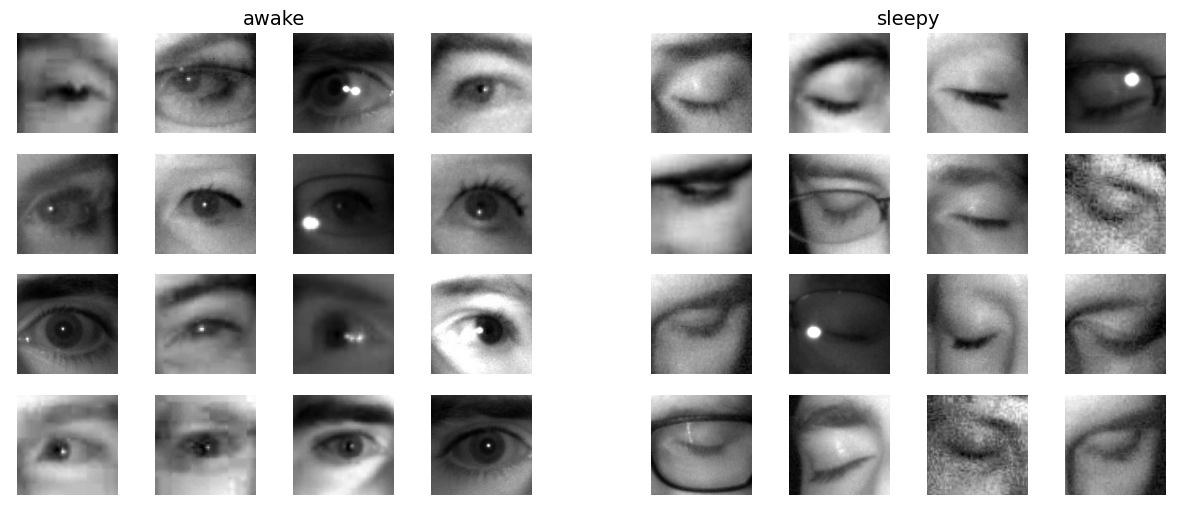

In [55]:
def show_random_image(PATH, num_of_samples=16):
    labels = os.listdir(PATH)

    fig = plt.figure(figsize=(15, 6))

    
    outer = fig.add_gridspec(1, 2, wspace=0.2)

    for j, label_name in enumerate(labels[:2]):
        label_path = os.path.join(PATH, label_name)
        images = shuffle(os.listdir(label_path))[:num_of_samples]

        
        inner = outer[j].subgridspec(4, 4)

        
        ax_title = fig.add_subplot(outer[j])
        ax_title.set_title(label_name, fontsize=14)
        ax_title.axis("off")

        for i, img_name in enumerate(images):
            r, c = divmod(i, 4)
            ax = fig.add_subplot(inner[r, c])
            img_path = os.path.join(label_path, img_name)
            ax.imshow(plt.imread(img_path), cmap="gray")
            ax.axis("off")

    plt.show()

show_random_image(TRAIN_PATH)

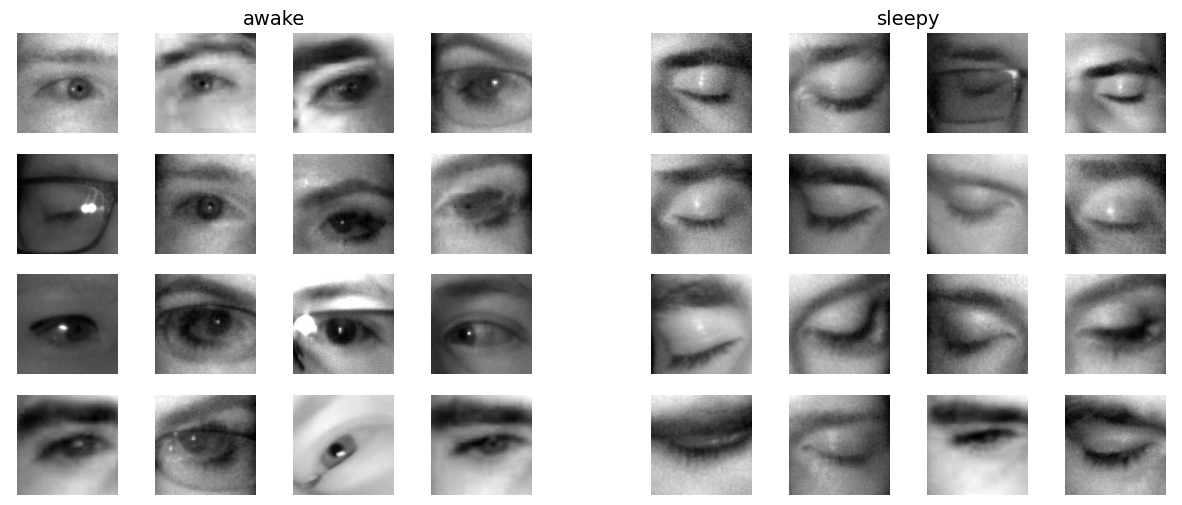

In [56]:
show_random_image(VAL_PATH)

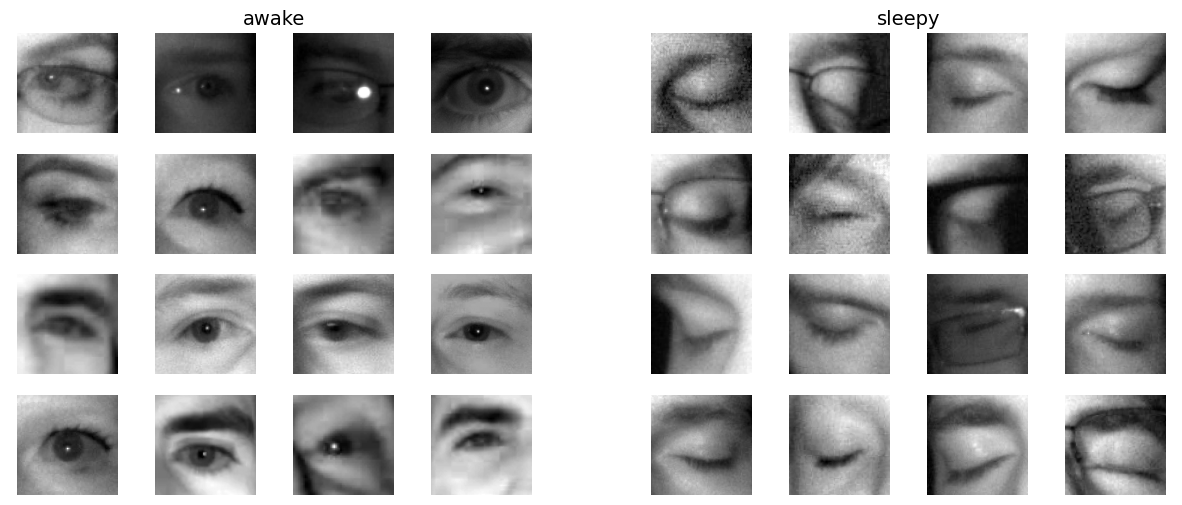

In [57]:
show_random_image(TEST_PATH)

In [58]:
def get_transforms(size=SIZE,apply_on_train=False):
    if apply_on_train:
        return transforms.Compose([transforms.Resize((size,size)),
                                   
                                   transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
                                   transforms.ColorJitter(0.35,0.35),
                                   transforms.RandomHorizontalFlip(),
                                   transforms.RandomRotation(30),
                                   transforms.RandomAffine(degrees=10, shear=15),

                                   transforms.ToTensor(),
                                   transforms.Normalize((0.5,), (0.5,)),
                                   ])
    else:
        return transforms.Compose([transforms.Resize((size,size)),

                                   transforms.ToTensor(),
                                   transforms.Normalize((0.5,), (0.5,)),
                                   ])

In [59]:
def prepare_dataloader(train_p,val_p,test_p,img_size=SIZE,batch_size=BATCH_SIZE):
    train_df = ImageFolder(train_p,get_transforms(img_size,True))
    val_df = ImageFolder(val_p,get_transforms(img_size))
    test_df = ImageFolder(test_p,get_transforms(img_size))

    print("Train length: ",len(train_df))
    print("Validation length: ",len(val_df))
    print("Test length: ",len(test_df))

    train_dl = DataLoader(train_df,batch_size,True,num_workers=0,pin_memory=True)
    val_dl = DataLoader(val_df,batch_size,False,num_workers=0,pin_memory=True)
    test_dl = DataLoader(test_df,batch_size,False,num_workers=0,pin_memory=True)

    print("The Data Is Succssfuly Loaded...!")
    return (train_dl,val_dl,test_dl)

In [60]:
train,val,test = prepare_dataloader(TRAIN_PATH,VAL_PATH,TEST_PATH)

Train length:  50937
Validation length:  16980
Test length:  16981
The Data Is Succssfuly Loaded...!
